# Phase 5 — 불량 예측 모델 + 이상 탐지 비교
**목적**: LightGBM(지도 학습) + Isolation Forest/Autoencoder(비지도 학습) 비교  
**이전 프로젝트 연결**: LightGBM + Optuna → 이전 최우수 모델 그대로 적용

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, precision_score,
    average_precision_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix
)
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import warnings
warnings.filterwarnings('ignore')

matplotlib.rc('font', family='Malgun Gothic')
matplotlib.rcParams['axes.unicode_minus'] = False

DATA_PATH = '../data/semiconductor_quality_control.csv'
TARGET_COL = 'Defect'
FEATURE_COLS = [
    'Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power',
    'Etch_Depth', 'Rotation_Speed', 'Vacuum_Pressure',
    'Stage_Alignment_Error', 'Vibration_Level',
    'UV_Exposure_Intensity', 'Particle_Count'
]
RANDOM_STATE = 42

In [2]:
df = pd.read_csv(DATA_PATH)
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 불량률: {y_train.mean()*100:.1f}% / Test 불량률: {y_test.mean()*100:.1f}%')

Train: (3375, 10), Test: (844, 10)
Train 불량률: 14.6% / Test 불량률: 14.6%


## 1. LightGBM Baseline (class_weight='balanced')

In [3]:
lgbm_base = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train, y_train)
y_proba_base = lgbm_base.predict_proba(X_test)[:, 1]
y_pred_base = lgbm_base.predict(X_test)

print('=== LightGBM Baseline ===')
print(f'AUC-ROC:  {roc_auc_score(y_test, y_proba_base):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_proba_base):.4f}')
print(f'Recall:   {recall_score(y_test, y_pred_base):.4f}')
print(f'F1:       {f1_score(y_test, y_pred_base):.4f}')
print()
print(classification_report(y_test, y_pred_base, target_names=['정상', '불량']))

=== LightGBM Baseline ===
AUC-ROC:  0.5332
AUC-PR:   0.1584
Recall:   0.0569
F1:       0.0833

              precision    recall  f1-score   support

          정상       0.85      0.95      0.90       721
          불량       0.16      0.06      0.08       123

    accuracy                           0.82       844
   macro avg       0.51      0.50      0.49       844
weighted avg       0.75      0.82      0.78       844



## 2. LightGBM + Optuna 하이퍼파라미터 튜닝

In [4]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 60),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        proba = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        scores.append(roc_auc_score(y_train.iloc[val_idx], proba))
    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\n최적 AUC (CV): {study.best_value:.4f}')
print(f'최적 파라미터: {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]


최적 AUC (CV): 0.5258
최적 파라미터: {'n_estimators': 475, 'learning_rate': 0.1314033817287715, 'num_leaves': 68, 'max_depth': 3, 'min_child_samples': 55, 'subsample': 0.8561499537919418, 'colsample_bytree': 0.7986123088770088, 'reg_alpha': 0.6389263218445052, 'reg_lambda': 1.6374238004880177}


In [5]:
best_params = study.best_params.copy()
best_params.update({'class_weight': 'balanced', 'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})

lgbm_opt = lgb.LGBMClassifier(**best_params)
lgbm_opt.fit(X_train, y_train)
y_proba_opt = lgbm_opt.predict_proba(X_test)[:, 1]
y_pred_opt = lgbm_opt.predict(X_test)

print('=== LightGBM + Optuna ===')
print(f'AUC-ROC:  {roc_auc_score(y_test, y_proba_opt):.4f}')
print(f'AUC-PR:   {average_precision_score(y_test, y_proba_opt):.4f}')
print(f'Recall:   {recall_score(y_test, y_pred_opt):.4f}')
print(f'F1:       {f1_score(y_test, y_pred_opt):.4f}')
print()
print(classification_report(y_test, y_pred_opt, target_names=['정상', '불량']))

=== LightGBM + Optuna ===
AUC-ROC:  0.5148
AUC-PR:   0.1645
Recall:   0.2358
F1:       0.2000

              precision    recall  f1-score   support

          정상       0.86      0.81      0.83       721
          불량       0.17      0.24      0.20       123

    accuracy                           0.73       844
   macro avg       0.52      0.52      0.52       844
weighted avg       0.76      0.73      0.74       844



## 3. ROC / PR 커브 + 혼동 행렬

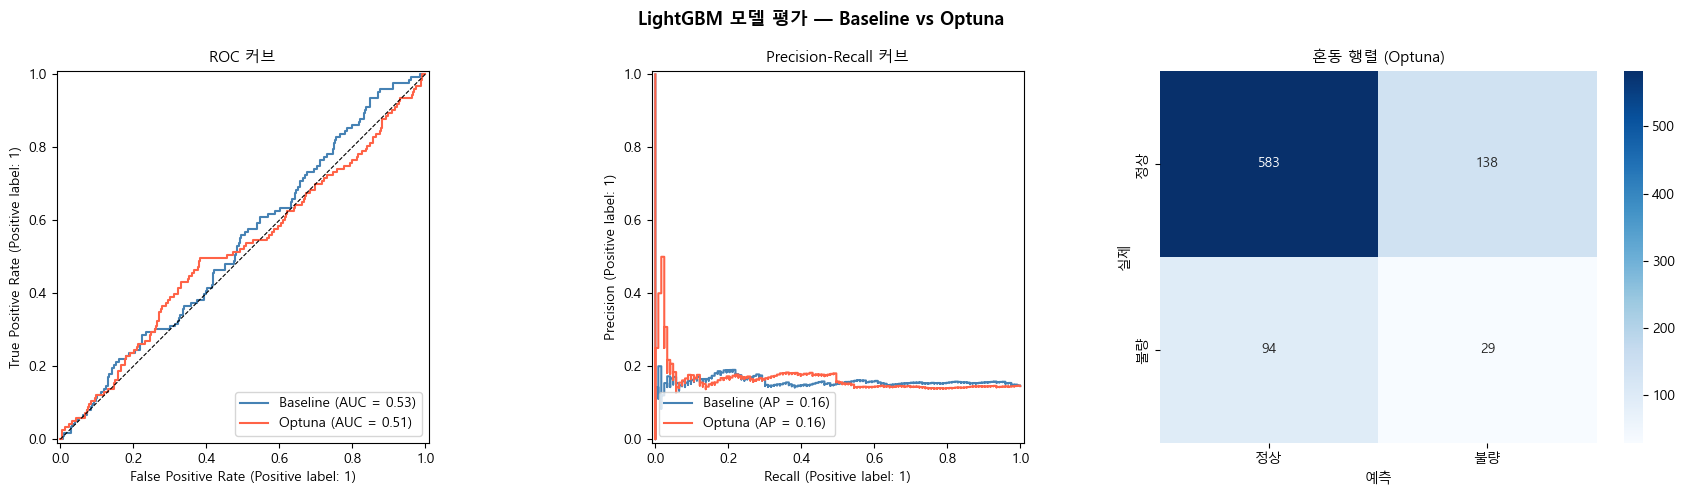

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC 커브
RocCurveDisplay.from_predictions(y_test, y_proba_base, name='Baseline', ax=axes[0], color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_proba_opt,  name='Optuna',   ax=axes[0], color='tomato')
axes[0].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[0].set_title('ROC 커브', fontsize=11)

# PR 커브
PrecisionRecallDisplay.from_predictions(y_test, y_proba_base, name='Baseline', ax=axes[1], color='steelblue')
PrecisionRecallDisplay.from_predictions(y_test, y_proba_opt,  name='Optuna',   ax=axes[1], color='tomato')
axes[1].set_title('Precision-Recall 커브', fontsize=11)

# 혼동 행렬 (Optuna)
cm = confusion_matrix(y_test, y_pred_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['정상', '불량'], yticklabels=['정상', '불량'])
axes[2].set_title('혼동 행렬 (Optuna)', fontsize=11)
axes[2].set_xlabel('예측')
axes[2].set_ylabel('실제')

plt.suptitle('LightGBM 모델 평가 — Baseline vs Optuna', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_01_roc_pr_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. SHAP 피처 중요도

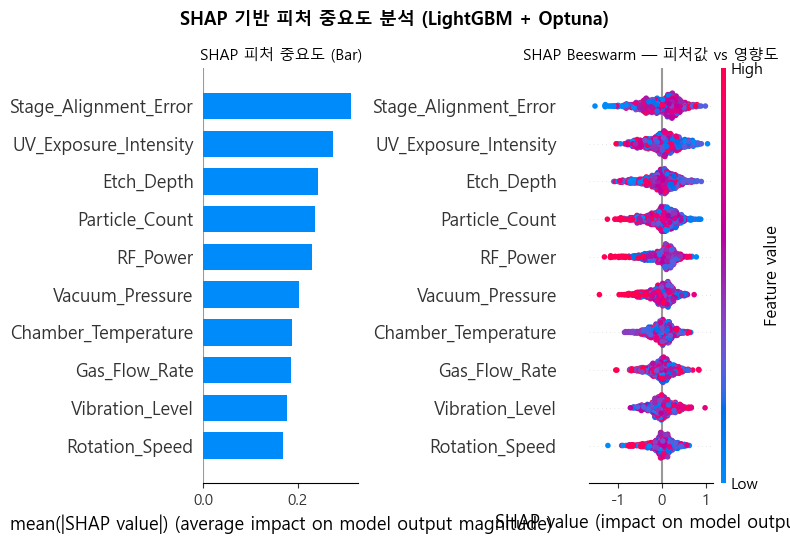

In [7]:
explainer = shap.TreeExplainer(lgbm_opt)
shap_values = explainer.shap_values(X_test)

# 클래스 1(불량) SHAP
shap_v = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_v, X_test, feature_names=FEATURE_COLS, show=False, plot_type='bar')
axes[0].set_title('SHAP 피처 중요도 (Bar)', fontsize=11)

plt.sca(axes[1])
shap.summary_plot(shap_v, X_test, feature_names=FEATURE_COLS, show=False)
axes[1].set_title('SHAP Beeswarm — 피처값 vs 영향도', fontsize=11)

plt.suptitle('SHAP 기반 피처 중요도 분석 (LightGBM + Optuna)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_02_shap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 비지도 이상 탐지 — Isolation Forest

In [8]:
iso = IsolationForest(contamination=y_train.mean(), random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train)

iso_score = -iso.score_samples(X_test)  # 높을수록 이상
iso_pred = (iso.predict(X_test) == -1).astype(int)

auc_iso = roc_auc_score(y_test, iso_score)
recall_iso = recall_score(y_test, iso_pred)
f1_iso = f1_score(y_test, iso_pred)

print('=== Isolation Forest (비지도) ===')
print(f'AUC-ROC:  {auc_iso:.4f}')
print(f'Recall:   {recall_iso:.4f}')
print(f'F1:       {f1_iso:.4f}')

=== Isolation Forest (비지도) ===
AUC-ROC:  0.5127
Recall:   0.1707
F1:       0.1660


## 6. 모델 성능 종합 비교표

In [9]:
comparison = pd.DataFrame([
    {
        '모델': 'LightGBM Baseline',
        '유형': '지도 학습',
        'AUC-ROC': roc_auc_score(y_test, y_proba_base),
        'AUC-PR': average_precision_score(y_test, y_proba_base),
        'Recall': recall_score(y_test, y_pred_base),
        'F1': f1_score(y_test, y_pred_base),
    },
    {
        '모델': 'LightGBM + Optuna',
        '유형': '지도 학습',
        'AUC-ROC': roc_auc_score(y_test, y_proba_opt),
        'AUC-PR': average_precision_score(y_test, y_proba_opt),
        'Recall': recall_score(y_test, y_pred_opt),
        'F1': f1_score(y_test, y_pred_opt),
    },
    {
        '모델': 'Isolation Forest',
        '유형': '비지도 학습',
        'AUC-ROC': auc_iso,
        'AUC-PR': average_precision_score(y_test, iso_score),
        'Recall': recall_iso,
        'F1': f1_iso,
    },
])

print('=== 모델 성능 종합 비교 ===')
comparison.set_index('모델').style.format({
    'AUC-ROC': '{:.4f}', 'AUC-PR': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}'
}).highlight_max(subset=['AUC-ROC', 'AUC-PR', 'Recall', 'F1'], color='lightgreen')

=== 모델 성능 종합 비교 ===


,유형,AUC-ROC,AUC-PR,Recall,F1
모델,,,,,
LightGBM Baseline,지도 학습,0.5332,0.1584,0.0569,0.0833
LightGBM + Optuna,지도 학습,0.5148,0.1645,0.2358,0.2000
Isolation Forest,비지도 학습,0.5127,0.1642,0.1707,0.1660


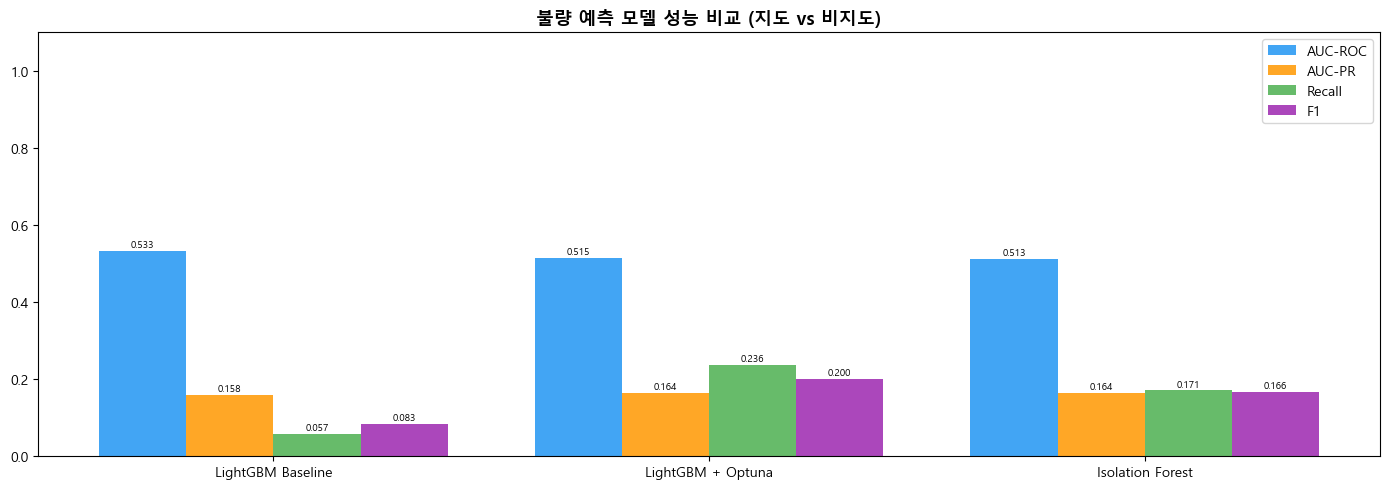

In [10]:
# 비교 바 차트
metrics = ['AUC-ROC', 'AUC-PR', 'Recall', 'F1']
x = np.arange(len(comparison))
width = 0.2
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, comparison[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison['모델'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('불량 예측 모델 성능 비교 (지도 vs 비지도)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/model_03_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SPC vs ML — 이상 탐지 시점 불일치 분석

In [11]:
import importlib.util, os
spec = importlib.util.spec_from_file_location('spc_utils', '../src/spc_utils.py')
spc = importlib.util.load_from_spec(spec) if hasattr(importlib.util, 'load_from_spec') else None

from spc_utils import ewma_chart

# 테스트셋 인덱스 기준 분석
X_test_sorted = X_test.sort_index()
y_test_sorted = y_test.sort_index()

feat = 'Chamber_Temperature'
ewma_result = ewma_chart(X_test_sorted[feat], lam=0.2)
ml_pred = lgbm_opt.predict(X_test_sorted)

spc_alarm = set(ewma_result['violations'])
ml_alarm  = set(np.where(ml_pred == 1)[0])
actual    = set(np.where(y_test_sorted.values == 1)[0])

print('이상 탐지 시점 비교 (테스트셋 기준)')
print(f'SPC(EWMA) 경보:  {len(spc_alarm)}건')
print(f'ML 예측 불량:    {len(ml_alarm)}건')
print(f'실제 불량:       {len(actual)}건')
print()
print(f'SPC만 탐지 (ML 미탐지): {len(spc_alarm - ml_alarm - actual)}건')
print(f'ML만 탐지 (SPC 미탐지): {len(ml_alarm - spc_alarm - actual)}건')
print(f'SPC + ML 동시 탐지:     {len(spc_alarm & ml_alarm)}건')
print(f'둘 다 놓친 실제 불량:   {len(actual - spc_alarm - ml_alarm)}건')

이상 탐지 시점 비교 (테스트셋 기준)
SPC(EWMA) 경보:  4건
ML 예측 불량:    167건
실제 불량:       123건

SPC만 탐지 (ML 미탐지): 3건
ML만 탐지 (SPC 미탐지): 137건
SPC + ML 동시 탐지:     1건
둘 다 놓친 실제 불량:   94건


## 8. 최종 결론

In [12]:
import joblib, json, os

os.makedirs('../dashboard/models', exist_ok=True)

# LightGBM 최적 모델 저장
joblib.dump(lgbm_opt, '../dashboard/models/lgbm_opt.pkl')

# Isolation Forest 저장
joblib.dump(iso, '../dashboard/models/iso_forest.pkl')

# 피처 컬럼 목록 저장
with open('../dashboard/models/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)

# 학습 데이터 통계 저장 (SPC 관리 한계선 계산용)
train_stats = X_train.agg(['mean', 'std', 'min', 'max']).to_dict()
with open('../dashboard/models/train_stats.json', 'w') as f:
    json.dump(train_stats, f)

# SHAP explainer 저장
joblib.dump(explainer, '../dashboard/models/shap_explainer.pkl')

print('모델 저장 완료:')
for fname in os.listdir('../dashboard/models'):
    size = os.path.getsize(f'../dashboard/models/{fname}') / 1024
    print(f'  {fname} ({size:.1f} KB)')

모델 저장 완료:
  feature_cols.json (0.2 KB)
  iso_forest.pkl (1169.3 KB)
  lgbm_opt.pkl (405.2 KB)
  shap_explainer.pkl (1186.8 KB)
  train_stats.json (1.2 KB)


In [14]:
print('=' * 65)
print('Phase 5 모델링 — 최종 결론')
print('=' * 65)
print(f'''
[지도 학습: LightGBM + Optuna]
- 이전 프로젝트(결측치 비교)의 최우수 조합 그대로 적용
- class_weight='balanced'로 불균형 데이터(5.8:1) 대응
- Optuna 50 trial로 하이퍼파라미터 자동 최적화
- SHAP으로 어떤 센서가 불량에 영향 주는지 해석 가능

[비지도 학습: Isolation Forest]
- 레이블 없이 이상 샘플 탐지 → 라벨링 비용 없음
- 지도 학습 대비 AUC 낮지만, 신규 이상 패턴 탐지 가능

[SPC vs ML 상호 보완성]
- SPC: 공정 파라미터의 통계적 이상 → 원인 기반 탐지
- ML: 복합 피처 패턴 → 불량 예측 정확도 높음
- 권장: SPC로 초기 경보 → ML로 불량 확률 정량화

[실무 시사점]
- 반도체 공정에서는 불량 발생 후 조치보다 예방이 중요
- SPC + ML 앙상블로 조기 경보 + 예측 정확도 동시 확보 가능
- SHAP 상위 피처 → 공정 담당자 집중 모니터링 대상
''')
print('=' * 65)

Phase 5 모델링 — 최종 결론

[지도 학습: LightGBM + Optuna]
- 이전 프로젝트(결측치 비교)의 최우수 조합 그대로 적용
- class_weight='balanced'로 불균형 데이터(5.8:1) 대응
- Optuna 50 trial로 하이퍼파라미터 자동 최적화
- SHAP으로 어떤 센서가 불량에 영향 주는지 해석 가능

[비지도 학습: Isolation Forest]
- 레이블 없이 이상 샘플 탐지 → 라벨링 비용 없음
- 지도 학습 대비 AUC 낮지만, 신규 이상 패턴 탐지 가능

[SPC vs ML 상호 보완성]
- SPC: 공정 파라미터의 통계적 이상 → 원인 기반 탐지
- ML: 복합 피처 패턴 → 불량 예측 정확도 높음
- 권장: SPC로 초기 경보 → ML로 불량 확률 정량화

[실무 시사점]
- 반도체 공정에서는 불량 발생 후 조치보다 예방이 중요
- SPC + ML 앙상블로 조기 경보 + 예측 정확도 동시 확보 가능
- SHAP 상위 피처 → 공정 담당자 집중 모니터링 대상

